# Final Homework — Unsupervised Learning, Dimensionality Reduction and Anomaly Detection

**Holon Institute of Technology (HIT) — Faculty of Computer Science**

| | |
|---|---|
| **Course** | Introduction to Data Science |
| **Assignment** | Final Homework |
| **Student name** | Sean Mazon |
| **ID number** | 212234660 |
| **Head lecturer** | Dr. Uri Itai |
| **Teaching assistant** | Hanit Hadad Ohayon |
| **Grader** | Dror Meirovich |
| **Submission deadline** | 18.09.2026 |

---

## Table of Contents

0. [Introduction](#0-introduction)
1. [Dataset Selection](#1-dataset-selection)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Dimensionality Reduction (PCA)](#3-dimensionality-reduction-pca)
4. [Clustering Analysis](#4-clustering-analysis)
5. [Multi-Dimensional Anomaly Detection](#5-multi-dimensional-anomaly-detection)
6. [Comparison of Anomaly Detection Methods](#6-comparison-of-anomaly-detection-methods)
7. [Critical Analysis and Reflection](#7-critical-analysis-and-reflection)
8. [Ethical Considerations](#8-ethical-considerations)
9. [Final Visualization Dashboard](#9-final-visualization-dashboard-optional)

## 0. Introduction

This chapter states the objective, the stance the analysis takes towards its own
results, and the methodology. It contains no code and no results; the analysis
begins in chapter 1.

### 0.1 Objective

The assignment sets out to explore the structure of a real-world dataset using
unsupervised methods: clustering, dimensionality reduction, and multi-dimensional
anomaly detection. No labels guide any part of it.

Its framing matters more than its component list. The assignment opens by
observing that unsupervised problems are **fundamentally ill-defined**: nothing
tells us how many clusters should exist, which observations are anomalous, or
whether meaningful clusters and anomalies exist at all. Different methods,
distance measures and parameter choices can lead to different conclusions, and
more than one may be reasonable.

Two consequences follow, and they govern how this notebook is written.

**First, the goal is not to produce output.** The assignment states plainly that
it does not grade "beautiful" clusters. It grades understanding of what the
methods assume, why they disagree, and what their results mean for the data.
Every algorithm applied here is therefore accompanied by its mathematical
intuition, its assumptions, and an account of where those assumptions fail on
this dataset.

**Second, a negative result is a legitimate result.** The assignment states
explicitly that an inability to find meaningful clusters, significant anomalies
or effective dimensionality reduction does not indicate poor analysis — the
structure may simply not be there. This notebook therefore commits in advance to
reporting weak or absent structure where that is what the evidence shows, rather
than selecting the parameters that produce the most attractive picture. Where
methods disagree, the disagreement is reported and examined rather than resolved
by preference.

### 0.2 Methodology

Each analytical section follows the same four-part pattern:

- **Method** — what is being done and why.
- **Results** — the actual numerical and visual output.
- **Interpretation** — what the results mean, including where they contradict
  what was expected.
- **Conclusion** — the single insight the section establishes.

Interpretations are written **after** the results have been read, never drafted
in advance. Where the data shows a pattern but cannot establish its cause, the
proposed cause is labelled as a hypothesis and the evidence that would test it is
named. Claims about what an algorithm "found" are kept separate from claims about
what is true of the games themselves.

The analysis proceeds in the order the assignment specifies: the dataset and its
provenance, exploratory analysis, PCA, clustering of both samples and features,
the three required anomaly detection methods, their comparison, critical
reflection, and ethical considerations.

### 0.3 What the Assignment Requires and What Is Chosen Here

The assignment fixes the analytical programme but leaves the material open. Kept
distinct throughout:

**Required by the assignment** — the five dataset selection criteria and the
provenance description; the exploratory, PCA, clustering, anomaly-detection,
comparison, reflection and ethics sections with their listed contents; at least
three clustering methods; clustering of the feature space as well as the samples;
all three anomaly detection methods; mathematical intuition for each method.

**Chosen here, and justified where it appears** — the dataset; which eight
features form the numeric matrix and which columns are held back; the log
transform applied to the heavy-tailed features; which three clustering algorithms
are used; how every hyperparameter is selected; and which evaluation metrics are
reported beyond the one the assignment names.

No choice in the second list is presented as though it came from the first.

## 1. Dataset Selection

**Method.** This chapter identifies the dataset, verifies it against the five
selection criteria, records what the source does and does not document, defines
every feature used, states which columns were excluded and why, and sets out the
limitations that constrain everything the later chapters can claim.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# The helper package for this assignment sits one level above the notebook and
# adds Assignment 1's package to the path, so the cleaning and the derived
# features defined there are reused unchanged rather than reimplemented.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from unsupervised.data_setup import (
    ANNOTATION_VARIABLES,
    LOG_TRANSFORMED_FEATURES,
    MODEL_FEATURES,
    NEW_FEATURES,
    ORIGINAL_FEATURES,
    PRIOR_ENGINEERED_FEATURES,
    SNAPSHOT_DATE,
    build_matrix,
    describe_feature_provenance,
    describe_source_file,
    load_analysis_frame,
    summarise_excluded_candidates,
    verify_selection_requirements,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

games = load_analysis_frame()
print(f"Rows loaded: {len(games):,}")

Rows loaded: 1,500


### 1.1 Source and Provenance

The dataset is the one used in Assignments 1 and 2, which the assignment
explicitly permits. It records the 1,500 highest-revenue games released on Steam
during 2024.

In [2]:
describe_source_file()

,Value
Property,
File,Steam_2024_bestRevenue_1500.csv
Size,"180,690 bytes (176.5 KB)"
Distributed via,"Kaggle, user 'alicemtopcu'"
Dataset URL,https://www.kaggle.com/datasets/alicemtopcu/top-1500-games-on-steam-by-revenue-09-09-2024
Extraction date,"2024-09-09, stated in the dataset title"
Why it was collected,Not specified by the source
Who originally collected it,Not specified by the source
Licence,Not recorded in the downloaded file
Methodology note,None supplied with the file


**Where the dataset comes from.** It was downloaded from Kaggle, from the dataset
*Top 1500 Games on Steam by Revenue (09-09-2024)*, published by the user
`alicemtopcu`. The extraction date of 9 September 2024 is stated in the dataset's
own title, and Assignment 1 corroborated it independently: the file's creation
timestamp is 11 September 2024, two days later, which is what a download delay
looks like.

**Why it was collected — not specified by the source.** The Kaggle page carries
no statement of purpose, and no datasheet, methodology note or licence file
accompanies the download. Nothing in the file records why it was assembled. The
field selection is consistent with commercial market intelligence rather than
research, but that is an inference from the shape of the data and is not
documented anywhere, so it is recorded as such rather than asserted.

**Who collected it — not specified by the source.** The Kaggle account is the
*distributor*, and a distributor is not necessarily the collector. The originating
producer is not named on the dataset page or in the file.

One fact bears on this and is verifiable independently: **Valve publishes no
per-title sales or revenue figures for Steam.** No public interface exposes how
many copies a game has sold. It follows that `revenue` and `copiesSold` cannot be
direct measurements and must be estimates produced by some third-party model.
Assignment 2 established the point quantitatively — regressing log revenue on log
copies and log price returned coefficients of 0.988 and 1.005 with an R² of
0.9901, recovering an accounting identity almost exactly. **Which** estimator
produced them, and with what error, is not stated. This is the single most
important property of the dataset for an anomaly-detection assignment, and
section 1.5 returns to it.

### 1.2 Verification Against the Selection Criteria

The assignment lists five criteria a dataset must satisfy. They are checked in
code rather than asserted.

In [3]:
verify_selection_requirements(games)

,Required,Observed,Status
Requirement,,,
"At least 1,000 rows",">= 1,000","1,500",PASS
At least 8 features,>= 8,"9 in the source file, excluding 2 identifiers; 8 used for modelling",PASS
Mostly numerical variables,majority numeric,5 of 9 source features are numeric; the modelling matrix is 8/8 numeric,PASS
Real-world dataset,yes,"Commercially released Steam titles, published on Kaggle",PASS
No pre-labeled anomaly column,none present,"No column encodes an outlier, anomaly or class label",PASS


**Results and interpretation.** All five criteria are satisfied, though two
deserve a precise reading rather than a tick.

**"At least 8 features."** The source file has 11 columns, two of which — `name`
and `steamId` — are identifiers with 1,500 distinct values apiece and carry no
distributional information. Excluding them leaves **9 analysable features**, above
the minimum. The numeric matrix built in section 1.3 uses **8** of them.

**"Mostly numerical variables."** Of the 9 analysable source features, **5 are
numeric** — a majority, so the criterion holds, but only just. This is the
dataset's weakest point against the assignment, since PCA, distance-based
clustering and multi-dimensional anomaly detection all operate on numeric
matrices. Section 1.3 sets out how a matrix of eight numeric features is obtained
without inventing anything for the purpose.

**"No pre-labeled anomaly column."** No column in the file encodes an outlier,
anomaly, or class label of any kind. Nothing in the analysis that follows has
access to a ground truth, which is the condition the assignment intends.

### 1.3 The Analysis Matrix, and Where Each Feature Came From

**Method.** A concern applies to any dataset that only narrowly meets a feature
count: features can always be manufactured to satisfy it, and manufactured
features distort exactly the analyses this assignment performs. Ratios of
existing columns create collinearity that PCA then reports as redundancy;
duplicate encodings of one variable create correlations that clustering then
reports as structure.

Each feature is therefore classified by origin, and the count is checked against
the requirement **without** any feature created for this assignment.

In [4]:
print(f"Original dataset columns                     : {len(ORIGINAL_FEATURES)}  {ORIGINAL_FEATURES}")
print(f"Engineered in Assignment 1, reused in A2     : {len(PRIOR_ENGINEERED_FEATURES)}  {PRIOR_ENGINEERED_FEATURES}")
print(f"Newly created for this assignment            : {len(NEW_FEATURES)}  {NEW_FEATURES or '[]'}")
print()
print(f"Modelling matrix                             : {len(MODEL_FEATURES)} features")
print(f"Minimum required by the assignment           : 8")
print(f"Requirement met without any new feature      : {len(ORIGINAL_FEATURES) + len(PRIOR_ENGINEERED_FEATURES) >= 8}")

display(describe_feature_provenance())

Original dataset columns                     : 5  ['copiesSold', 'price', 'revenue', 'avgPlaytime', 'reviewScore']
Engineered in Assignment 1, reused in A2     : 3  ['daysOnSale', 'publisherReleaseCount', 'selfPublished']
Newly created for this assignment            : 0  []

Modelling matrix                             : 8 features
Minimum required by the assignment           : 8
Requirement met without any new feature      : True


,Provenance,Meaning,Unit
Feature,,,
copiesSold,Original column,Estimated lifetime units sold at the snapshot date,count
price,Original column,Listed store price; zero denotes a free-to-play title,USD (currency not stated by the source; inferred)
revenue,Original column,Estimated lifetime gross revenue at the snapshot date,USD (currency and gross/net basis not stated; inferred)
avgPlaytime,Original column,Average time played per owner,hours (unit not stated; inferred from the observed range)
reviewScore,Original column,"Share of user reviews that are positive; 0 is a placeholder, not a score","percent, 0-100 (definition not stated; inferred)"
daysOnSale,Engineered in Assignment 1,"Days between release and the 2024-09-09 snapshot, i.e. exposure",days
publisherReleaseCount,Engineered in Assignment 1,Titles in this dataset by the most prolific publisher credited on the game,count
selfPublished,Engineered in Assignment 1,"1 when the publisher and developer strings match, 0 otherwise",binary


**Interpretation — what each feature represents.** The table above gives the
meaning and unit of all eight. Three points are worth drawing out.

**Five features are original columns** and three were derived in Assignment 1 and
reused unchanged in Assignment 2. **No feature was created for this assignment.**
The eight-feature minimum is met by 5 + 3 = 8, so nothing was engineered to reach
the threshold.

**Several units are inferred rather than documented.** The source states no
currency for `price` and `revenue`, no unit for `avgPlaytime`, and no definition
for `reviewScore`. USD, hours and percent-positive are the only readings
consistent with the observed ranges, but they are inferences. An undocumented
unit is a limitation of the data, and marking it visibly is more honest than
silently adopting the obvious guess.

**Two features are not continuous measurements**, which matters for methods that
assume continuity:

- `selfPublished` is **binary**. It is a legitimate feature — Assignment 1 found
  publisher and developer identical for roughly half the catalogue — but a
  balanced binary variable cannot produce a large standardised deviation, so it
  can never contribute to a Z-score anomaly. Section 5.1 measures this directly.
  It also carries full weight in Euclidean distance once standardised, so it
  influences clustering considerably. That is a property of the **representation**
  chosen, not of any tuning parameter, and section 4 examines it under that
  heading.
- `publisherReleaseCount` is a **count computed within this dataset**. Because
  the dataset was selected on revenue, a studio appears often partly because
  several of its titles earned well, so the feature carries a faint trace of the
  selection. Assignment 2 measured its rank correlation with log revenue at 0.12.

In [5]:
summarise_excluded_candidates()

,Would have been,Reason for exclusion
Column,,
publisherTier,Would have been new for this assignment,Ordinal encoding of plotClass. Excluded on evidence: a Z-score on it flags exactly the 52 AAA ti...
releaseMonth,Would have been new for this assignment,Correlates -0.99 with daysOnSale because both derive from releaseDate. Including both would crea...
"revenuePerCopy, revenuePerDay, priceRealisation",Engineered in Assignment 1,"Algebraic functions of features already in the matrix, so they would manufacture collinearity ra..."
"name, steamId",Original columns,"Identifiers with 1,500 distinct values; carry no distributional signal."
"publishers, developers",Original columns,"Free-text with 1,131 and 1,406 distinct values; not numeric and not encodable at this cardinalit..."
"plotClass, priceBand, isFreeToPlay",Engineered in Assignment 1,Categorical. Held back as annotations used to interpret and validate the clusters and anomalies ...


**Interpretation — what was excluded, and why.** Two exclusions were decided on
measured evidence rather than preference, and both would have corrupted later
chapters had they been kept.

**`publisherTier`** — an ordinal encoding of studio scale (Indie < AA < AAA) —
was the only candidate that would have been newly created here. It was rejected
on three independent grounds. A Z-score computed on it flags exactly the 52 AAA
titles, which would convert a **studio label into a statistical anomaly** and
contaminate chapter 5. It raises the number of components needed for 90% of
variance from six to seven, adding a dimension without adding structure. And it
lowers the k = 3 silhouette from 0.195 to 0.181. Encoding three categories
as 0, 1, 2 also imposes an arbitrary claim that the step
from Indie to AA equals the step from AA to AAA, which directly distorts every
distance computed from it. `plotClass` is therefore retained as an **annotation**:
it is used to interpret and validate the clusters and anomalies that the methods
find, which is more informative than burying it inside a distance metric.

**`releaseMonth`** correlates **−0.99** with `daysOnSale`, because both are
functions of the release date under a fixed snapshot. Including both would have
placed a near-duplicate pair in the matrix, and PCA would then have reported the
resulting redundancy as a finding about the data rather than an artefact of the
feature set.

The three ratio features from Assignment 1 — `revenuePerCopy`, `revenuePerDay`
and `priceRealisation` — are algebraic functions of columns already present and
were excluded for the same reason.

In [6]:
analysis_matrix = build_matrix(games, log_transform=False)

print(f"Matrix shape                : {analysis_matrix.shape[0]:,} x {analysis_matrix.shape[1]}")
print(f"All columns numeric         : {analysis_matrix.dtypes.apply(lambda d: d.kind in 'ifb').all()}")
print(f"Duplicate rows              : {analysis_matrix.duplicated().sum()}")
print(f"Constant columns            : {[c for c in analysis_matrix if analysis_matrix[c].nunique() <= 1] or 'none'}")
print()
print("Missing values (placeholders converted by the Assignment 1 cleaning):")
print(analysis_matrix.isna().sum().loc[lambda counts: counts > 0].to_string())
print()
print(f"Annotation variables held out of the matrix : {ANNOTATION_VARIABLES}")
print(f"Heavy-tailed features to be log-transformed : {LOG_TRANSFORMED_FEATURES}")
print(f"Snapshot date used for daysOnSale           : {SNAPSHOT_DATE:%Y-%m-%d}")

Matrix shape                : 1,500 x 8
All columns numeric         : True
Duplicate rows              : 0
Constant columns            : none

Missing values (placeholders converted by the Assignment 1 cleaning):
avgPlaytime     1
reviewScore    99

Annotation variables held out of the matrix : ['name', 'steamId', 'plotClass', 'priceBand', 'isFreeToPlay']
Heavy-tailed features to be log-transformed : ['copiesSold', 'revenue', 'avgPlaytime', 'publisherReleaseCount']
Snapshot date used for daysOnSale           : 2024-09-09


**Results.** The matrix is 1,500 × 8, fully numeric, with no duplicate rows and
no constant columns. Two features carry missing values — 99 in `reviewScore` and
one in `avgPlaytime` — and both are the placeholder zeros identified in Assignment
1, converted to missing values by the cleaning imported from it rather than left
in as scores of zero. Leaving them would have created a spurious group of 99
identical-looking games that every clustering and anomaly method would then have
reported as structure. Imputation is deferred to the point of use so that each
method's sensitivity to it can be examined.

### 1.4 Annotation Variables

Three categorical columns are deliberately excluded from the numeric matrix and
retained for interpretation: `plotClass` (studio scale), `priceBand`, and
`isFreeToPlay`. Together with `name` they allow a cluster or a flagged anomaly to
be described in terms a reader can recognise — "this cluster is mostly cheap indie
titles", "this anomaly is a free-to-play game" — without those descriptions having
influenced the geometry that produced them.

This separation is what makes the later validation meaningful. If clusters
discovered from eight numeric features turn out to align with studio scale, that
is evidence the structure is real, precisely because studio scale was not
available to the algorithm.

### 1.5 Limitations and Biases

**Method.** The assignment requires possible limitations and biases to be stated.
Four apply here, and each constrains what later chapters may legitimately claim.

**1. Survivorship: the sample is selected on the quantity of greatest interest.**
These are the 1,500 highest-earning games of 2024. They are not a sample of games
on Steam; they are its commercial upper tail. Every statement about distributions,
clusters or anomalies in this notebook therefore describes structure **within an
already-successful population**. An observation flagged as anomalous is anomalous
relative to other top earners, not relative to Steam. Assignment 1 measured one
consequence directly: the relationship between how long a game had been on sale
and how much it earned is absent in this sample, because selecting on revenue
removes it.

**2. The monetary columns are estimates, not measurements.** As section 1.1 set
out, Valve publishes no sales figures, so `revenue` and `copiesSold` are the
output of an undisclosed third-party model with unknown systematic error and no
confidence interval. For an anomaly-detection assignment this is the most
consequential limitation of all: **a point flagged as anomalous may be an
artefact of the estimator rather than an unusual game.** Chapter 6 must therefore
distinguish three possibilities for every flagged observation — a genuine rare
case, a data error, and an estimation artefact — and the dataset alone cannot
always separate them.

**3. Documented placeholders remain a hazard.** `reviewScore` used 0 for "no
score available" in 99 rows and `avgPlaytime` used 0 in one. Both are handled, but
they illustrate that this file encodes missingness as valid numbers. Any
undiscovered instance of the same pattern would be read by every method in this
notebook as a dense group of ordinary observations.

**4. Coverage stops on 6 September 2024.** The fourth quarter — which contains
the Black Friday and winter sales, commercially the most important weeks of the
year — is absent entirely. Structure that is seasonal will not be visible.

**Conclusion.** The dataset satisfies all five selection criteria, and the
eight-feature numeric matrix is built from five original columns and three
features validated in earlier assignments, with nothing engineered to meet the
threshold. Its principal weaknesses are that it is a truncated, revenue-selected
sample and that its two most important variables are modelled rather than
observed. Both are carried forward explicitly rather than noted and forgotten:
the first bounds the population any conclusion describes, and the second bounds
what "anomaly" can be taken to mean.

## 2. Exploratory Data Analysis

**Method.** This chapter does three things. It establishes the structure and
completeness of the matrix; it characterises the distribution of every feature
with a histogram, a box plot, its skewness and its kurtosis; and it examines the
extreme values, distinguishing heavy tails from noise, measurement artefacts and
data-entry problems.

It also settles one preprocessing question that chapters 3 to 5 all depend on:
whether to analyse the heavy-tailed features on their original scale or on a
logarithmic one. That decision is taken here from measurements rather than
assumed in the chapter that first needs it.

In [7]:
from unsupervised.eda import (
    correlation_shift,
    distribution_statistics,
    outlier_counts,
    structural_summary,
)
from unsupervised.plots import (
    apply_house_style,
    plot_boxplot_grid,
    plot_correlation_pair,
    plot_distribution_grid,
    plot_transform_effect,
)

apply_house_style()

raw_matrix = build_matrix(games, log_transform=False)
log_matrix = build_matrix(games, log_transform=True)

structural_summary(games, raw_matrix)

,Value
Property,
Rows,"1,500"
Features in the matrix,8
Columns available in the loaded frame,28
Total cells in the matrix,"12,000"
Missing cells,100 (0.833%)
Features with missing values,"reviewScore (99), avgPlaytime (1)"
Duplicate rows,0
Constant features,none
Numeric dtypes,8 of 8


### 2.1 Structural Analysis

In [8]:
display(raw_matrix.dtypes.rename("dtype").to_frame())
raw_matrix.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2)

,dtype
copiesSold,int64
price,float64
revenue,float64
avgPlaytime,float64
reviewScore,float64
daysOnSale,int64
publisherReleaseCount,int64
selfPublished,int64


,count,mean,std,min,1%,25%,50%,75%,99%,max
copiesSold,1500.0,141482.57,1132756.66,593.00,1132.99,4918.75,11928.50,37869.75,2087213.99,3.073915e+07
price,1500.0,17.52,12.65,0.00,0.00,9.99,14.99,19.99,59.99,9.999000e+01
revenue,1500.0,2632381.98,27810239.62,20674.00,21259.08,45504.25,109053.00,455156.75,34683031.82,8.377934e+08
avgPlaytime,1499.0,12.57,21.55,0.55,0.88,3.57,6.76,13.11,96.51,2.963300e+02
reviewScore,1401.0,81.59,13.92,11.00,37.00,75.00,85.00,92.00,99.00,1.000000e+02
daysOnSale,1500.0,127.11,68.16,3.00,4.99,74.00,130.00,186.00,245.01,2.520000e+02
publisherReleaseCount,1500.0,3.22,4.28,1.00,1.00,1.00,1.00,3.00,22.00,2.200000e+01
selfPublished,1500.0,0.49,0.50,0.00,0.00,0.00,0.00,1.00,1.00,1.000000e+00


**Results and interpretation.** The matrix is 1,500 × 8 with every column
numeric, no duplicate rows and no constant features. **100 cells are missing —
0.833% of the matrix** — confined to `reviewScore` (99) and `avgPlaytime` (1).
Both are the placeholder zeros documented in chapter 1, converted to missing
values rather than left in as valid measurements.

The summary table already shows why this dataset needs care. For `revenue` the
**mean is $2,632,382 and the median $109,053** — the mean is 24 times the
median, which is possible only if a small number of observations are enormous.
`copiesSold` behaves the same way: mean 141,483 against a median of 11,929. The
99th percentile of revenue is $34.7M while the maximum is $838M, so the top
percentile alone spans a further factor of 24.

Three features behave quite differently and are worth noting because they will
matter later. `daysOnSale` runs from 3 to 252 with a median of 130 and shows no
sign of a tail. `reviewScore` is bounded at 100 and concentrated near it, with a
median of 85. `selfPublished` is binary with a mean of 0.49, so the catalogue
splits almost evenly between self-published and externally published titles.

### 2.2 Distribution Analysis

**Method.** The assignment asks for a histogram, a box plot, the skewness and
the kurtosis of each major feature. All four are reported below for all eight
features. Skewness measures asymmetry, and kurtosis measures how much of the
variance comes from rare extreme values rather than typical ones; a normal
distribution has an excess kurtosis of 0.

In [9]:
distribution_statistics(raw_matrix, log_matrix)

,Skew (raw),Kurtosis (raw),Log applied,Skew (analysis scale),Kurtosis (analysis scale),Distinct values
Feature,,,,,,
copiesSold,18.60,420.0,yes,0.98,1.4,1460
price,1.58,3.9,no,1.58,3.9,58
revenue,22.90,607.8,yes,1.19,1.5,1497
avgPlaytime,7.16,71.5,yes,0.35,0.2,1499
reviewScore,-1.31,2.1,no,-1.31,2.1,71
daysOnSale,-0.05,-1.1,no,-0.05,-1.1,235
publisherReleaseCount,2.50,6.0,yes,1.18,0.2,16
selfPublished,0.04,-2.0,no,0.04,-2.0,2


**Results.** The eight features fall into three clearly separated groups.

**Extremely heavy-tailed (two features).** `revenue` has a skewness of **22.90**
and an excess kurtosis of **607.8**; `copiesSold` has 18.60 and 420.0. For
reference, a normal distribution has 0 and 0. Kurtosis of this magnitude means
essentially all of the variance is contributed by a handful of observations.

**Moderately skewed (three).** `avgPlaytime` at 7.16, `publisherReleaseCount` at
2.50 and `price` at 1.58.

**Well behaved or bounded (three).** `reviewScore` is the only **left**-skewed
feature at −1.31, reflecting a ceiling at 100 with most games clustered near it.
`daysOnSale` has a skewness of −0.05 and an excess kurtosis of −1.1, which is
close to **uniform** — releases are spread evenly across the covered period.
`selfPublished` has an excess kurtosis of −2.0, the theoretical minimum, which is
simply what a balanced binary variable looks like.

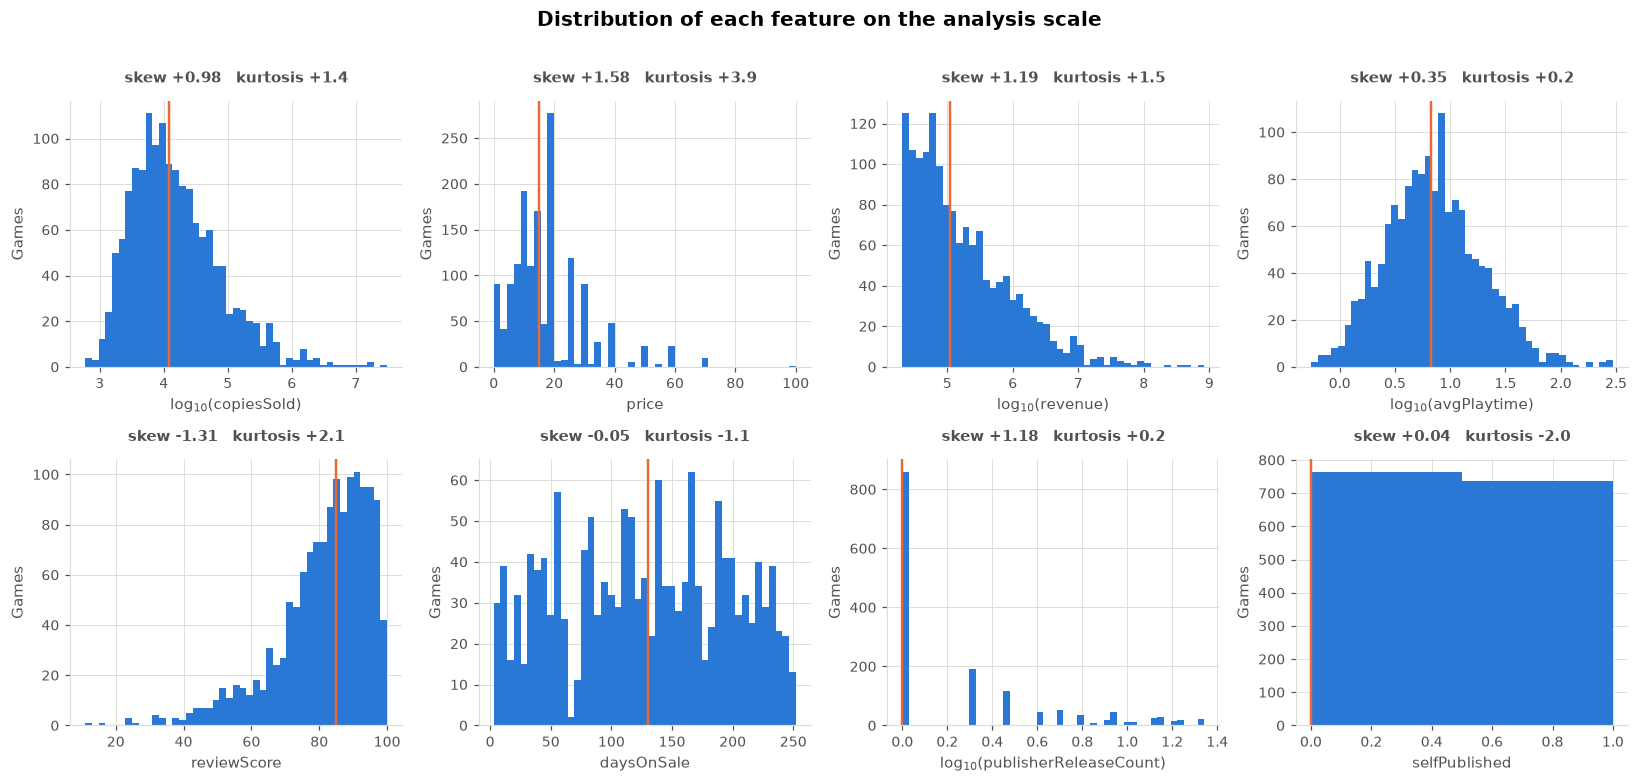

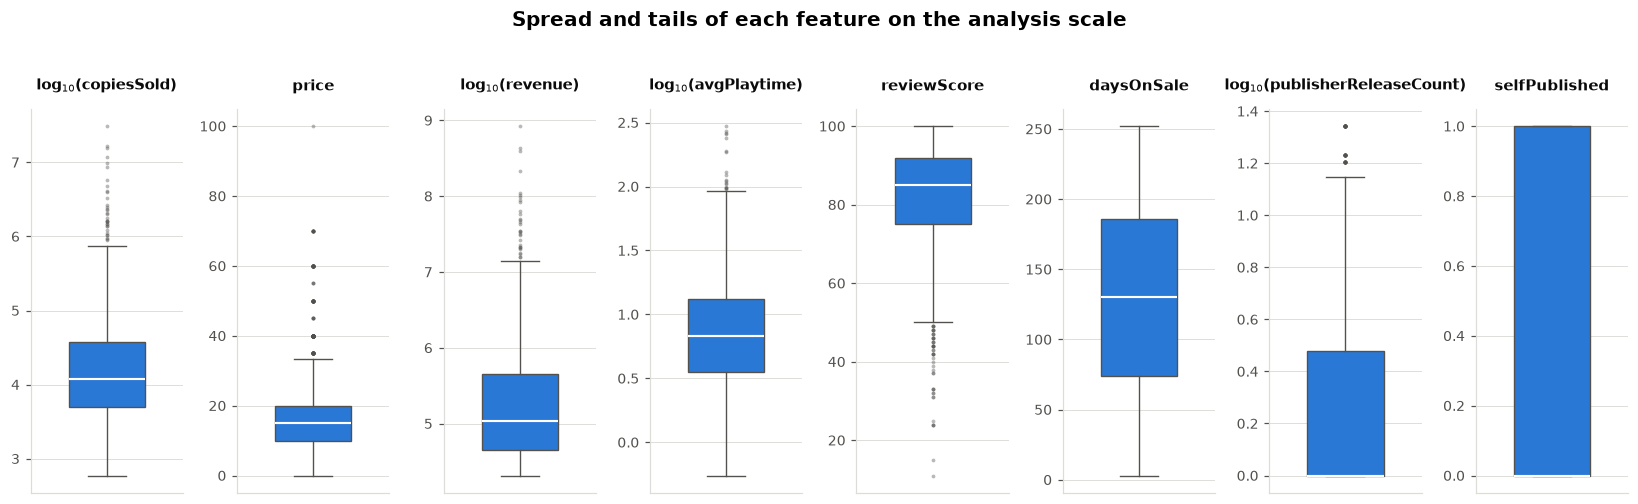

In [10]:
display(plot_distribution_grid(
    log_matrix, LOG_TRANSFORMED_FEATURES,
    "Distribution of each feature on the analysis scale",
))
display(plot_boxplot_grid(
    log_matrix, LOG_TRANSFORMED_FEATURES,
    "Spread and tails of each feature on the analysis scale",
))

**Interpretation of the figures.** Plotted on the scale used for the rest of the
analysis, the shapes become legible and several are informative in their own
right.

`log10(copiesSold)` and `log10(avgPlaytime)` are close to symmetric and unimodal
— a single population rather than distinct groups. `log10(revenue)` retains a
visible right tail even after the transform.

**`price` shows a distinctive comb pattern** rather than a smooth distribution:
tall spikes at a few values with near-empty space between them. This is not
noise. It is psychological pricing, and it means `price` is effectively a
discrete variable with a small number of levels rather than a continuous
measurement. Section 2.4 treats it as a measurement artefact.

`daysOnSale` is visibly flat, confirming the near-uniformity the statistics
indicated, and its box plot has **no points outside the whiskers at all**.

`selfPublished` is a two-bar histogram, which is the honest picture of a binary
feature and a reminder that it does not carry the kind of information the
distance-based methods in later chapters are designed to exploit.

### 2.3 The Preprocessing Decision: Should the Heavy Tails Be Transformed?

**Method.** PCA, K-Means, DBSCAN, hierarchical clustering, LOF and the Z-score
method are all built on variances or distances. A feature with a skewness of 22.9
dominates any such quantity: after standardisation, one observation can sit 30
standard deviations from the mean while 99% of the data occupies a fraction of a
single unit.

The alternative is a base-10 logarithm on the four positively skewed features.
Rather than assume it is an improvement, the decision is made by measuring what
it does to the distributions and to the relationships between them.

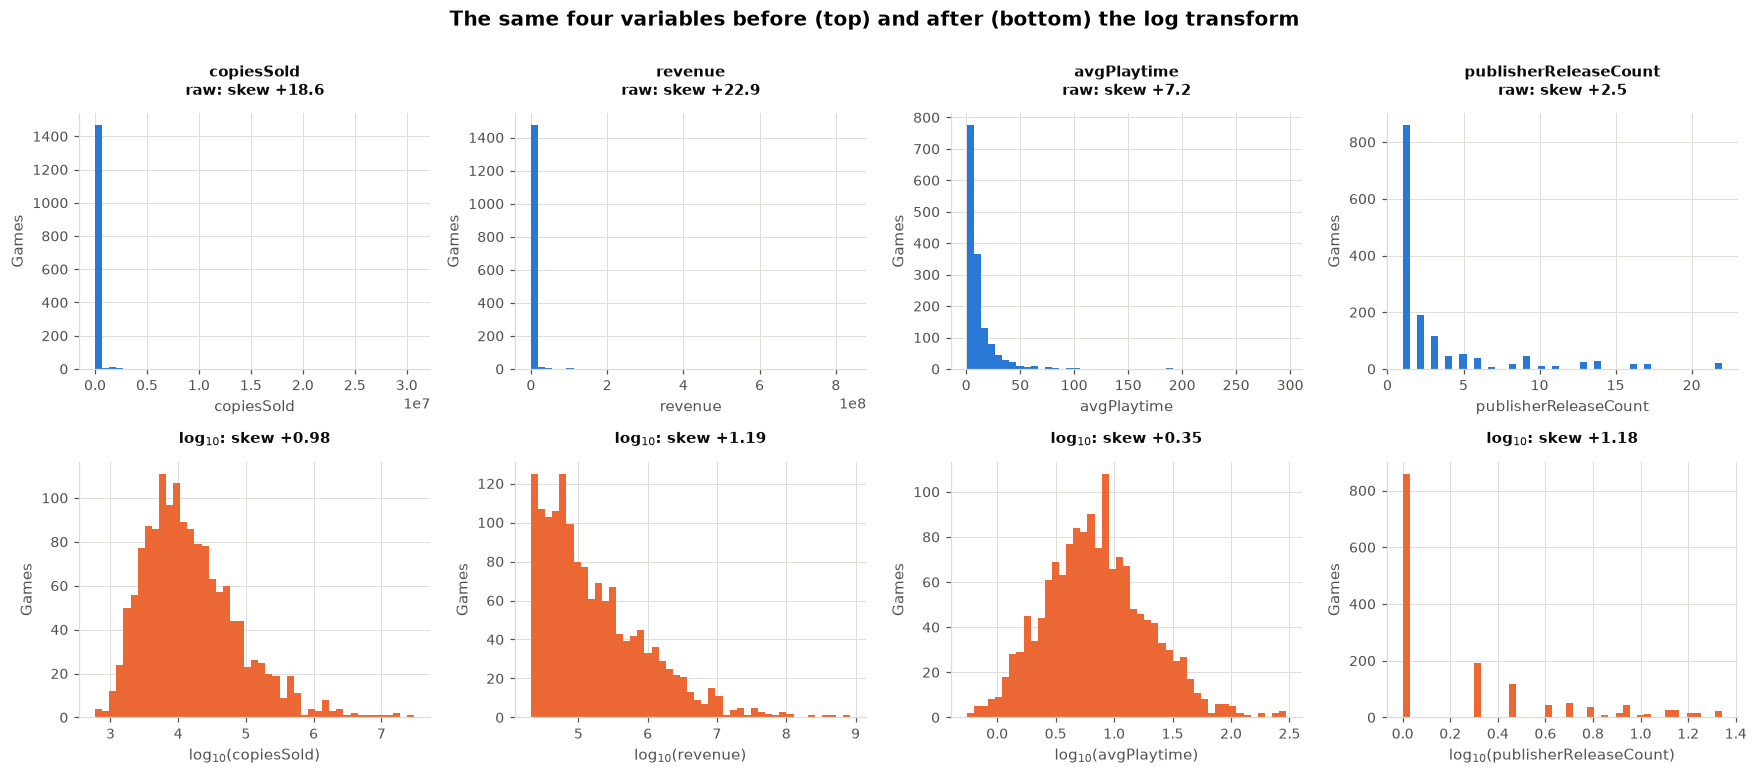

,r (raw),r (log),Change in |r|
Pair,,,
revenue ~ avgPlaytime,0.082,0.453,0.371
copiesSold ~ revenue,0.628,0.897,0.269
copiesSold ~ avgPlaytime,0.099,0.354,0.255
price ~ revenue,0.163,0.398,0.235
price ~ avgPlaytime,0.030,0.255,0.225
publisherReleaseCount ~ selfPublished,-0.426,-0.539,0.113
revenue ~ selfPublished,0.015,-0.120,0.105
price ~ publisherReleaseCount,0.086,0.181,0.095


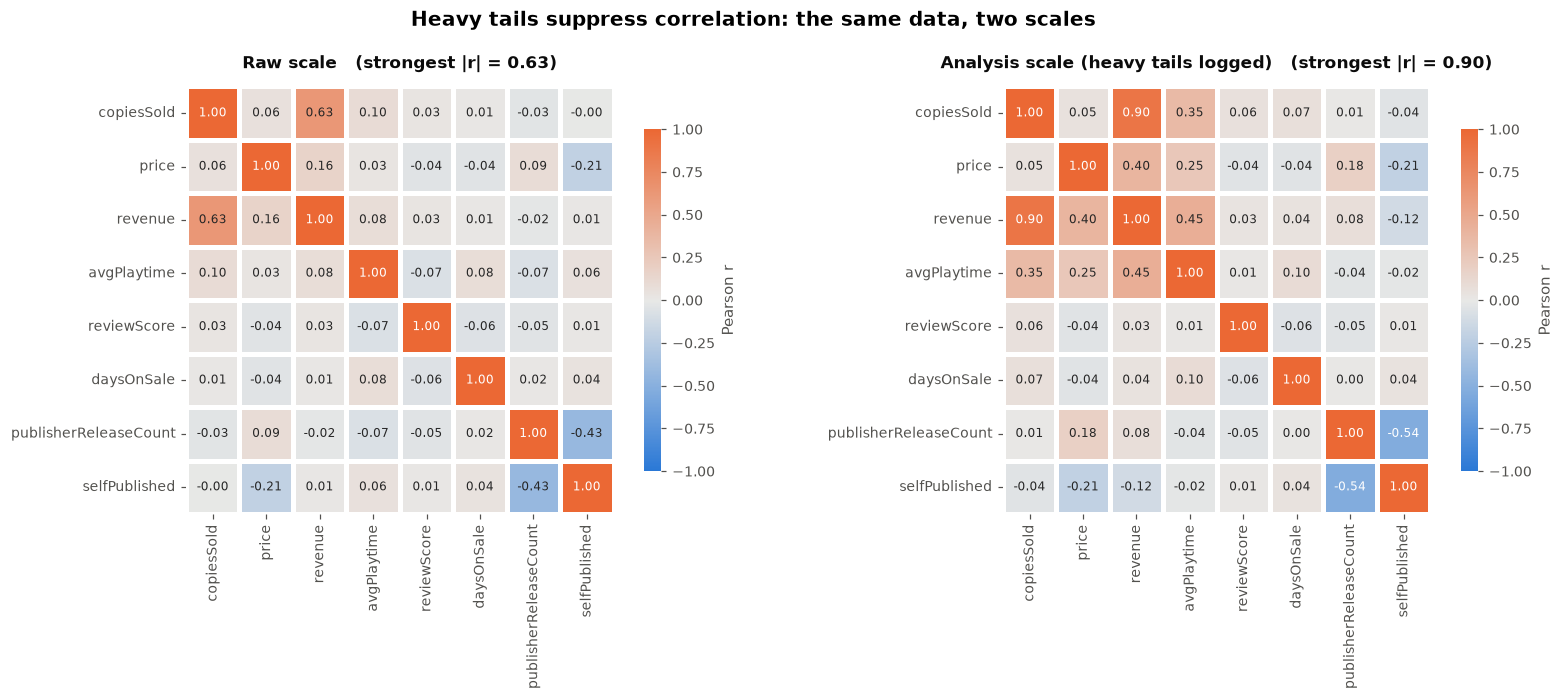

In [11]:
display(plot_transform_effect(raw_matrix, log_matrix, LOG_TRANSFORMED_FEATURES))
display(correlation_shift(raw_matrix, log_matrix).head(8))
display(plot_correlation_pair(raw_matrix, log_matrix))

**Results.** The transform changes both the shapes and the measured
relationships, and the second effect is the more consequential.

| Feature | Skew before → after | Kurtosis before → after |
|---|---|---|
| `revenue` | 22.90 → **1.19** | 607.8 → **1.5** |
| `copiesSold` | 18.60 → **0.98** | 420.0 → **1.4** |
| `avgPlaytime` | 7.16 → **0.35** | 71.5 → **0.2** |
| `publisherReleaseCount` | 2.50 → 1.18 | 6.0 → 0.2 |

**Every pairwise correlation involving a transformed feature becomes stronger,
several of them dramatically:**

| Pair | r (raw) | r (log) | Change |
|---|---|---|---|
| `revenue ~ avgPlaytime` | 0.082 | **0.453** | +0.371 |
| `copiesSold ~ revenue` | 0.628 | **0.897** | +0.269 |
| `copiesSold ~ avgPlaytime` | 0.099 | **0.354** | +0.255 |
| `price ~ revenue` | 0.163 | **0.398** | +0.235 |
| `price ~ avgPlaytime` | 0.030 | **0.255** | +0.225 |

The strongest relationship anywhere in the matrix rises from **0.63 to 0.90**.

**Interpretation.** The raw scale does not merely make the distributions awkward
to plot — **it conceals the structure of the data.** On the raw scale,
`avgPlaytime` and `revenue` correlate at 0.082, a value any analyst would read as
"no relationship". On the log scale the same two variables correlate at 0.453.
Nothing about the data changed; the extreme values were dominating the
covariance, and the relationship among the remaining 99% of games was being
averaged away.

The `copiesSold ~ revenue` pair is the clearest case. Assignment 2 established
that this dataset's vendor computes revenue as approximately copies × price, and
that a regression on the logged variables recovers the identity with coefficients
of 0.988 and 1.005. That relationship is **multiplicative**, so it appears as a
straight line only in log space. On the raw scale it reads as 0.63; on the log
scale, 0.90 — much closer to the near-deterministic link it actually is.

This has a direct consequence for chapter 3. PCA finds directions of maximum
variance in a linear space; if the strongest genuine relationship in the data is
multiplicative, PCA on the raw scale would be looking for the wrong kind of
structure and would spend its first component describing the tail of a single
variable.

**One honest qualification.** The transform is not a universal improvement.
`publisherReleaseCount` is a discrete count with 16 levels and 858 of the 1,500
games sitting at the value 1; taking logarithms reduces its skew from 2.50 to
1.18 but cannot make a spike at a single value into a continuous distribution.
Its histogram remains lumpy, and no transform will change that.

**Conclusion.** The four positively skewed features — `copiesSold`, `revenue`,
`avgPlaytime` and `publisherReleaseCount` — are analysed on a base-10 logarithmic
scale. `price`, `reviewScore`, `daysOnSale` and `selfPublished` are used as they
are: none has a heavy tail, and two are not continuous. Standardisation is
applied on top of this within each method's own pipeline, since PCA and every
distance-based method here would otherwise be dominated by whichever feature
happens to have the largest units.

### 2.4 Outlier Exploration

**Method.** The assignment asks for a discussion of heavy tails, extreme values,
possible noise, measurement artefacts and data-entry problems. These are
different things, and this section keeps them separate: an extreme value is not
necessarily an error, and an error is not necessarily extreme.

Two conventional rules are applied on both scales, not to identify the "real"
outliers but to demonstrate that the count depends on choices the analyst makes.

In [12]:
outlier_counts(raw_matrix, log_matrix)

,"|z| > 3, raw","|z| > 3, analysis scale","1.5xIQR, raw","1.5xIQR, analysis scale"
Feature,,,,
copiesSold,10,17,201,33
price,34,34,140,140
revenue,8,20,223,30
avgPlaytime,24,7,147,17
reviewScore,17,17,48,48
daysOnSale,0,0,0,0
publisherReleaseCount,39,0,199,55
selfPublished,0,0,0,0


**Results.** The number of flagged points depends heavily on both the rule and
the scale.

| Feature | 1.5×IQR raw | 1.5×IQR log | \|z\|>3 raw | \|z\|>3 log |
|---|---|---|---|---|
| `revenue` | 223 | **30** | **8** | **20** |
| `copiesSold` | 201 | 33 | 10 | 17 |
| `avgPlaytime` | 147 | 17 | 24 | 7 |
| `publisherReleaseCount` | 199 | 55 | 39 | **0** |
| `daysOnSale` | 0 | 0 | 0 | 0 |

**Interpretation.** Two findings here are worth more than the counts themselves.

**The IQR rule and the Z-score rule disagree in opposite directions on the same
variable.** For `revenue`, moving to the log scale takes the IQR count *down*
from 223 to 30, while it takes the Z-score count *up* from 8 to 20. The IQR rule
responds to the skew: on the raw scale the quartiles sit close together and the
upper fence falls far below most of the tail, so a seventh of the dataset is
flagged. The Z-score behaves in the opposite way, and the reason is the more
instructive one: **on the raw scale the extreme values inflate the standard
deviation used to judge them.** With a standard deviation of $27.8M, a threshold
of three standard deviations sits at roughly $86M, and only eight games in 1,500
clear it. The outliers hide themselves by making the yardstick enormous. This is
the masking effect, and it is a preview of exactly why chapter 5.1 must treat the
Z-score method's Gaussian assumption sceptically.

**`daysOnSale` has no outliers under any rule on any scale.** Its near-uniform
distribution has nothing that either rule can call extreme. It is a useful
control: it shows that these methods are not flagging points indiscriminately.

**The four categories the assignment asks about, with examples from this
dataset.**

**Heavy tails.** *Black Myth: Wukong* earned $837.8M from 15.5M copies. The next
four largest earn $436M, $392M, $217M and $111M. These are not errors, and they
are not separable from the distribution — they are its tail. Commercial success
in this market is generated multiplicatively, and the resulting distribution has
no natural cut point beyond which a game becomes "too successful to be real".

**Extreme values that are legitimate.** *Firestone: Online Idle RPG* records an
average playtime of **296 hours**, more than 40 times the median of 6.8. Three of
the four highest playtimes belong to free-to-play idle games, a genre designed to
run continuously for months. *The First Descendant* earns **$102M at a listed
price of zero.** Every one of these will be flagged by the methods in chapter 5,
and none is an error. They are a coherent subpopulation — free-to-play
live-service titles — that the feature set describes poorly because `price` says
nothing about how such a game monetises.

**Data-entry problems.** *The Elder Scrolls Online: Gold Road* was recorded with
an average playtime of exactly 0 despite 27,601 owners and $960,791 in revenue.
An MMO expansion cannot have zero average playtime; the value is a placeholder
for a field the source could not populate. The same applies to the 99 games whose
review score was stored as 0: Assignment 1 established that this group **outsells
the scored games**, which a genuine 0% approval rating cannot explain. Both were
converted to missing values in chapter 1. They are the clearest illustration in
this dataset of an error that is not extreme in the ordinary sense — a 0 sits
inside the plausible range of both variables and would pass any range check.

**Measurement artefacts.** `price` takes only **58 distinct values across 1,500
games**, and the six most common cover 54% of the catalogue — $19.99 alone
accounts for 230 games. This is a real property of how games are priced, but for
this analysis it is an artefact: `price` is presented as a continuous variable
and is not one. Distances computed along it are quantised, and any method that
assumes a continuous density will be working against the data. A second and more
serious artefact was established in chapter 1: `revenue` and `copiesSold` are
**model output rather than measurements**, so an extreme value in either may
reflect the estimator's behaviour rather than the game's.

**Possible noise.** With review scores recorded to the nearest percent and
playtimes to fourteen decimal places, the file gives no direct evidence of
measurement noise, and none can be separated from genuine variation without
repeated observations of the same title. What can be said is that the estimation
process is itself a source of uncertainty of unknown size, and chapter 7 returns
to the difficulty of distinguishing that from real variation.

**Conclusion.** The dataset contains a very large number of extreme values, but
few of them are errors. Its two most important variables are heavy-tailed by
nature rather than by contamination, and the log transform adopted in 2.3 makes
them tractable without removing anything. The errors that do exist are
placeholders that sit *inside* the normal range rather than outside it, which is
the harder kind to find. Most importantly for the chapters that follow, the count
of "outliers" in this dataset ranges from 0 to 223 for a single feature depending
on the rule and the scale chosen — **there is no scale-free answer to how many
anomalies this data contains**, which is precisely the ill-posedness the
assignment sets out to examine.

## 3. Dimensionality Reduction (PCA)

*Not yet written.* Explained variance ratio, cumulative variance, scree plot, 2D and 3D projections, component loadings, and the discussion of redundancy, stability, local versus global structure and interpretability.

## 4. Clustering Analysis

*Not yet written.* At least three clustering methods with their mathematical intuition, assumptions and evaluation; clustering of the feature space via the transposed matrix; and the discussion of why the algorithms disagree.

## 5. Multi-Dimensional Anomaly Detection

*Not yet written.* The main part of the assignment: the Z-score method, Isolation Forest and Local Outlier Factor, each with its assumptions, parameters and visualisation.

## 6. Comparison of Anomaly Detection Methods

*Not yet written.* Agreement and disagreement between the three methods, their sensitivity to scaling and dimensionality, runtime, robustness, interpretability, and what false positives and false negatives mean for this dataset in plain terms.

## 7. Critical Analysis and Reflection

*Not yet written.* Why anomaly detection is ill-defined, the curse of dimensionality, distance in high dimensions, noise versus genuine anomaly, the risks of assuming Gaussianity, and why post-projection visualisations can mislead.

## 8. Ethical Considerations

*Not yet written.* False alarms, surveillance, medical and cybersecurity applications, and the privacy, bias and fairness consequences of labelling behaviour as abnormal.

## 9. Final Visualization Dashboard (Optional)

*Not yet written.* Optional bonus. To be attempted only once every required section is complete.